# AXON INC.
##### This project analyzes the sales data of Axon Inc. to understand how leads turn into customers and how much revenue is generated from opportunities. The goal of this analysis is to study important metrics such as lead conversion rate, win rate, expected revenue, and industry performance to help improve business decisions.

---

#### Business Objective:
##### The goal of this analysis is to evaluate lead generation performance, opportunity conversion, and revenue contribution across industries and product categories. The insights help identify where the sales team is most successful and where improvements can increase revenue.

---

#### Contents:
##### 1. Project Overview
##### 2. Data Loading
##### 3. Data Cleaning
##### 4. Key Performance Indicators (KPIs)
##### 5. Lead Analysis
##### 6. Opportunity Analysis
##### 7. Revenue Analysis
##### 8. Machine Learning Prediction
##### 9. Feature Importance
##### 10. Model Conclusion
##### 11. Key Insights
##### 12. Business Recommendations
##### 13. Future Improvements

---

### Import Libraries
##### The following libraries are used for data analysis and visualization. Pandas helps in working with structured data, NumPy is used for numerical calculations, and Matplotlib and Plotly are used to create charts to better understand the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# chart style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

---

### Import Data
##### The data includes information about leads, opportunities, accounts, opportunity products, and users. These datasets together help us understand the complete sales process from generating leads to closing deals.

In [2]:
lead = pd.read_csv("Lead.csv")
opportunity = pd.read_csv("Opportunity.csv")
account = pd.read_csv("Account.csv")
opp_product = pd.read_csv("Opportunity Product.csv")
user = pd.read_csv("User.csv")

---

In [3]:
print("Lead dataset:", lead.shape)
print("Opportunity dataset:", opportunity.shape)
print("Account dataset:", account.shape)
print("Opportunity Product dataset:", opp_product.shape)
print("User dataset:", user.shape)

Lead dataset: (10000, 27)
Opportunity dataset: (4646, 26)
Account dataset: (3052, 23)
Opportunity Product dataset: (10000, 16)
User dataset: (98, 17)


---

### Data Cleaning
##### The Amount column contains symbols like $ and commas which prevent numerical calculations. These symbols are removed and the column is converted into numeric format so that financial calculations can be performed correctly.

In [4]:
opportunity["Amount"] = opportunity["Amount"].replace('[\$,]', '', regex=True).astype(float)

lead["Converted"] = lead["Converted"].astype(bool)

opportunity["Created Date"] = pd.to_datetime(opportunity["Created Date"])

---

# LEAD Analysis

### 1. Total Leads
##### Total Leads shows the total number of potential customers generated. A higher number of leads means more potential business opportunities.

In [5]:
total_leads = lead.shape[0]
print("Total Leads:", total_leads)

Total Leads: 10000


---

### 2. Expected Amount from Converted Leads
##### This metric shows the total revenue generated from opportunities that were successfully converted into customers.

In [6]:
expected_amount = opportunity.loc[
    opportunity["Stage"] == "Closed Won", "Amount"
].sum()

formatted_value = f"${expected_amount/1_000_000:.2f}M"

print("Expected Amount:", formatted_value)

Expected Amount: $136.26M


---

### 3. Conversion Rate
##### Conversion Rate shows the percentage of leads that successfully became customers. A higher conversion rate indicates that the sales team is effective in turning leads into actual customers.
Conversion Rate=(ConvertedLeads/TotalLeads)×100

In [7]:
converted_count = lead["Converted"].sum()

conversion_rate = (converted_count / total_leads) * 100

print("Conversion Rate:", round(conversion_rate,2), "%")

Conversion Rate: 10.33 %


---

### 4. Converted Accounts
##### Converted Accounts shows the number of unique companies that became customers after successful opportunity closure.

In [8]:
converted_accounts = opportunity.loc[
    opportunity["Stage"] == "Closed Won", "Account ID"
].nunique()

print("Converted Accounts:", converted_accounts)

Converted Accounts: 492


---

### 5. Converted Opportunities
##### Converted Opportunities represents the number of deals that were successfully closed as Closed Won.

In [9]:
converted_opportunities = opportunity.loc[
    opportunity["Stage"] == "Closed Won"
].shape[0]

print("Converted Opportunities:", converted_opportunities)

Converted Opportunities: 1443


---

## Data Visualization
##### The following visualizations help analyze lead generation, opportunity outcomes, and revenue distribution across industries and product categories.

### 6. Lead by Source
##### This chart shows where most of the leads are coming from. It helps identify the most effective sources for generating leads.

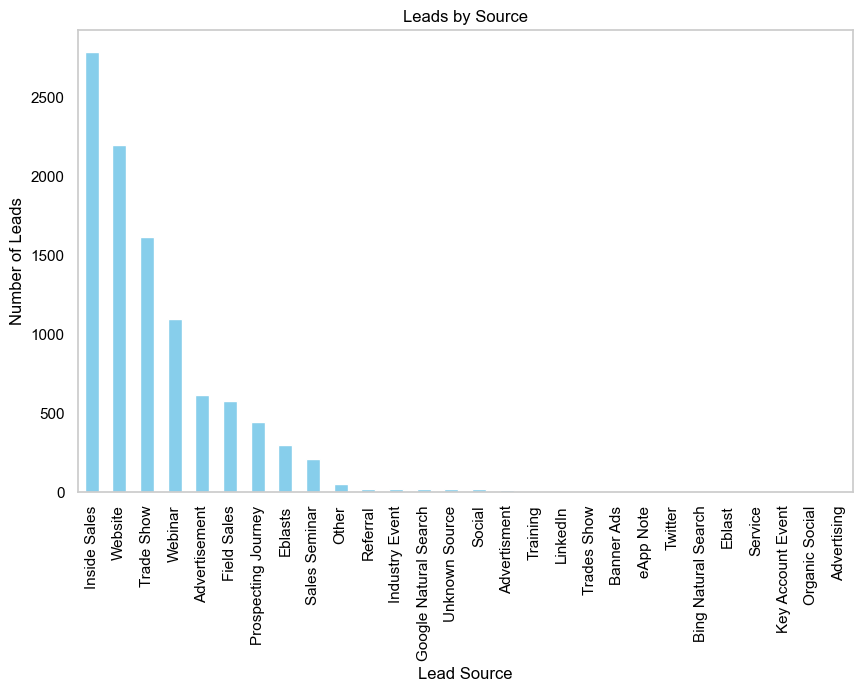

In [10]:
lead_source = lead["Lead Source"].value_counts()

ax = lead_source.plot(kind="bar", color="skyblue")

# Remove grid lines
ax.grid(False)

# Title and labels (black color)
plt.title("Leads by Source", color="black")
plt.xlabel("Lead Source", color="black")
plt.ylabel("Number of Leads", color="black")

# Tick labels in black
plt.xticks(color="black")
plt.yticks(color="black")

plt.show()

---

### 7. Lead by Industry
##### This chart shows which industries are generating the highest number of leads. It helps understand which industries show the most interest in the company's products or services.

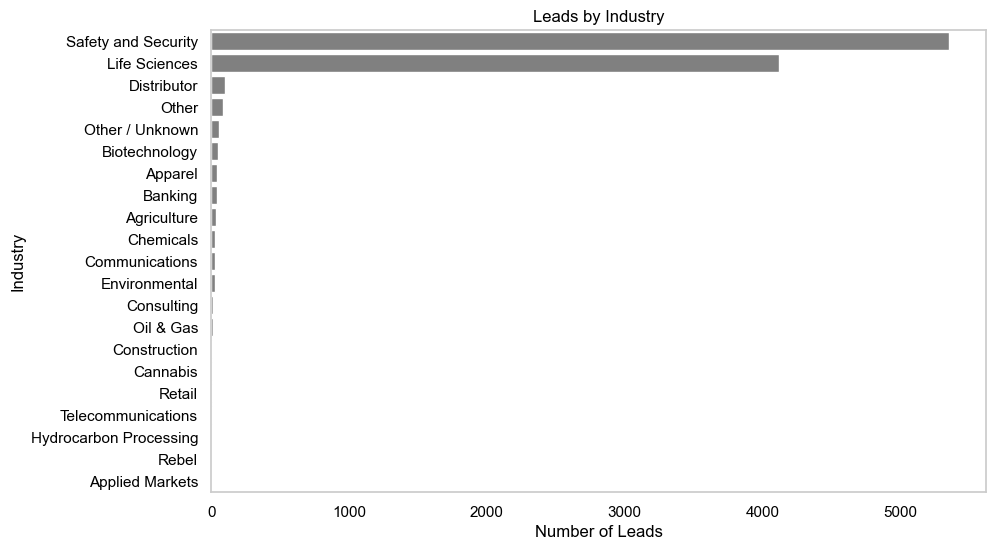

In [11]:
industry = lead["Industry"].value_counts()

ax = sns.barplot(x=industry.values, y=industry.index, color="grey")

# Remove grid lines
ax.grid(False)

# Title and labels
plt.title("Leads by Industry", color="black")
plt.xlabel("Number of Leads", color="black")
plt.ylabel("Industry", color="black")

# Tick label colors
plt.xticks(color="black")
plt.yticks(color="black")

plt.show()

---

### 8. Lead by Stage
##### This chart shows the different stages of leads and how they move through the sales process.

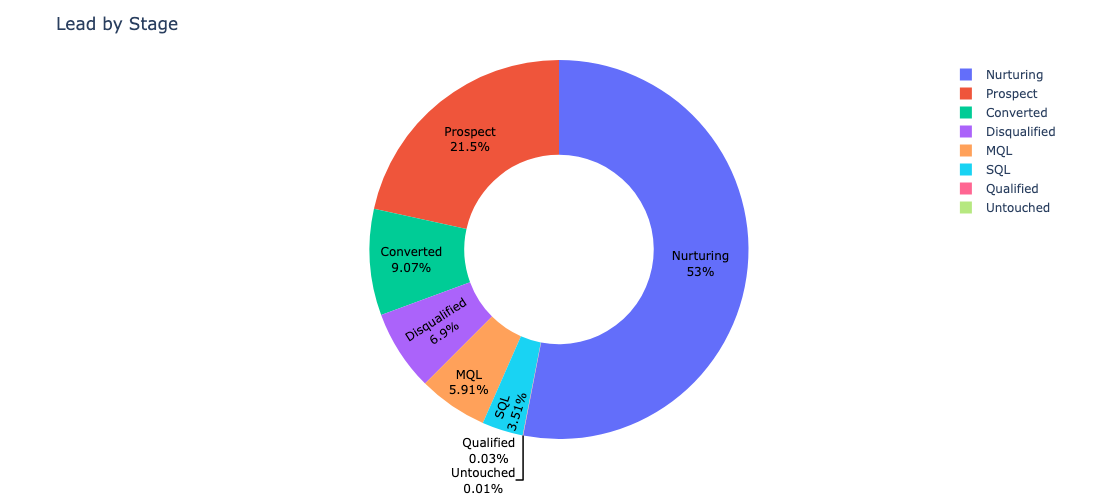

In [12]:
stage = lead["Status"].value_counts().reset_index()
stage.columns = ["Stage", "Count"]

fig = px.pie(
    stage,
    values="Count",
    names="Stage",
    hole=0.5,
    title="Lead by Stage"
)

fig.update_traces(
    textinfo="percent+label",
    textfont=dict(color="black")
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

---

# OPPORTUNITY Analysis

### 9. Expected Amount
##### Expected Amount represents the possible revenue that can be generated from current opportunities based on their probability of closing.

In [13]:
expected_amount = (
    opportunity["Amount"].replace('[\$,]', '', regex=True).astype(float)
    * opportunity["Probability (%)"].replace('%','', regex=True).astype(float) / 100
).sum()

# convert to millions format
formatted_value = f"${expected_amount/1_000_000:.2f}M"

print("Expected Amount:", formatted_value)

Expected Amount: $186.15M


---

### 10. Active Opportunities
##### Active Opportunities represent deals that are still open and have not been closed yet.

In [14]:
active_opportunities = opportunity[~opportunity["Stage"].str.contains("Closed", na=False)]

print("Active Opportunities:", active_opportunities.shape[0])

Active Opportunities: 1272


---

### 11. Opportunity Conversion Rate

Conversion Rate=(WonOpportunities/TotalOpportunities)×100

In [15]:
won = opportunity[opportunity["Stage"] == "Closed Won"].shape[0]

total_opportunities = opportunity.shape[0]

opp_conversion_rate = (won / total_opportunities) * 100

print("Opportunity Conversion Rate:", round(opp_conversion_rate,2),"%")

Opportunity Conversion Rate: 31.06 %


---

### 12. Win Rate
##### Win Rate shows the percentage of opportunities that were successfully closed compared to all completed opportunities.
Win Rate=Won/(Won+Lost)

In [16]:
won = opportunity[opportunity["Stage"] == "Closed Won"].shape[0]
lost = opportunity[opportunity["Stage"] == "Closed Lost"].shape[0]

win_rate = (won / (won + lost)) * 100

print("Win Rate:", round(win_rate,2),"%")

Win Rate: 42.77 %


---

### 13. Loss Rate
##### Loss Rate shows the percentage of opportunities that were lost. This helps understand where improvements may be needed.

In [17]:
loss_rate = (lost / total_opportunities) * 100

print("Loss Rate:", round(loss_rate,2),"%")

Loss Rate: 41.56 %


---

## Data Visualization
##### The following visualizations help analyze lead generation, opportunity outcomes, and revenue distribution across industries and product categories.

### 14. Expected vs Forecast Revenue Trend
##### This chart compares the expected revenue and forecast revenue over time. It helps understand how the potential revenue is changing across different time periods.

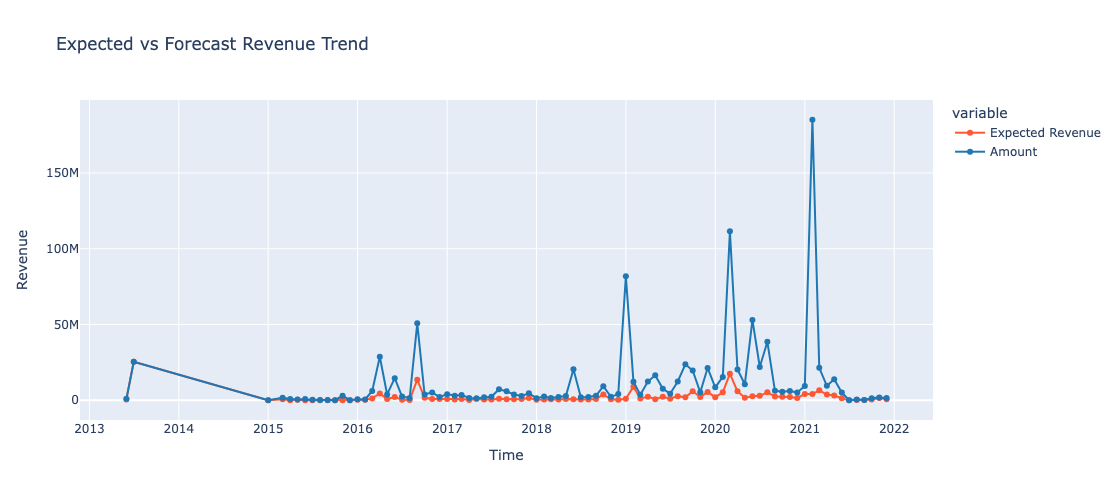

In [18]:
# Expected Revenue
opportunity["Expected Revenue"] = opportunity["Amount"] * (opportunity["Probability (%)"] / 100)

# Create Month column
opportunity["Month"] = pd.to_datetime(opportunity["Created Date"]).dt.to_period("M").dt.to_timestamp()

trend = (
    opportunity.groupby("Month")[["Expected Revenue","Amount"]]
    .sum()
    .reset_index()
)

fig = px.line(
    trend,
    x="Month",
    y=["Expected Revenue","Amount"],
    title="Expected vs Forecast Revenue Trend",
    markers=True,
    color_discrete_sequence=["#FF5733","#1F77B4"]
)

fig.update_layout(
    xaxis_title="Time",
    yaxis_title="Revenue",
    height=500
)

fig.show()

---

### 15. Active vs Total Opportunities
##### This chart compares the number of active opportunities with the total number of opportunities. It helps understand how many deals are still in progress compared to the total deals created.

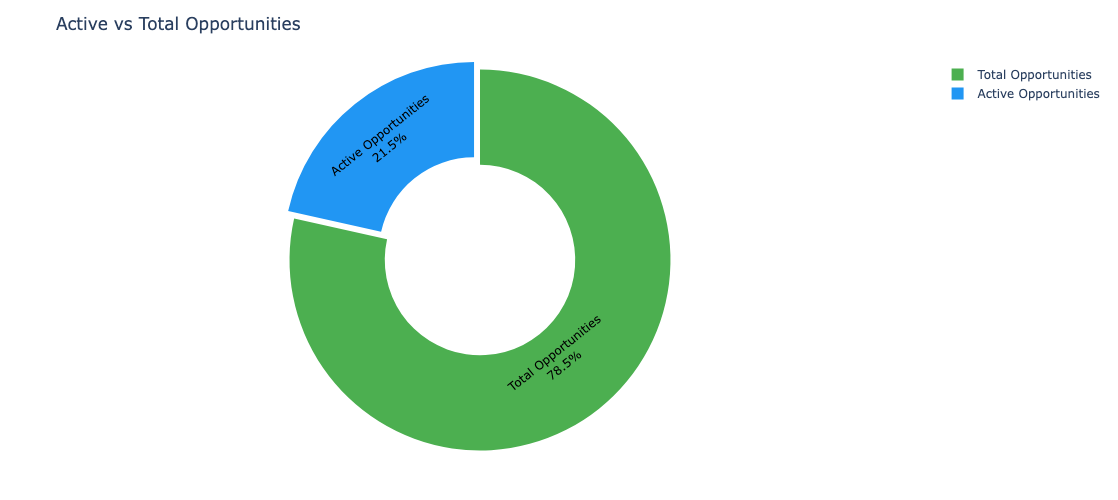

In [19]:
active = opportunity[~opportunity["Stage"].str.contains("Closed", na=False)]

data = pd.DataFrame({
    "Type": ["Active Opportunities", "Total Opportunities"],
    "Count": [active.shape[0], opportunity.shape[0]]
})

fig = px.pie(
    data,
    values="Count",
    names="Type",
    hole=0.5,
    title="Active vs Total Opportunities",
    color_discrete_sequence=["#4CAF50", "#2196F3"]
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05,0],
    textfont=dict(color="black")
)

fig.update_layout(
    height=500,
    margin=dict(t=60,b=40,l=40,r=40)
)

fig.show()

---

### 16. Closed Won vs Total Opportunities
##### This chart compares the number of opportunities that were successfully closed with the total number of opportunities created.

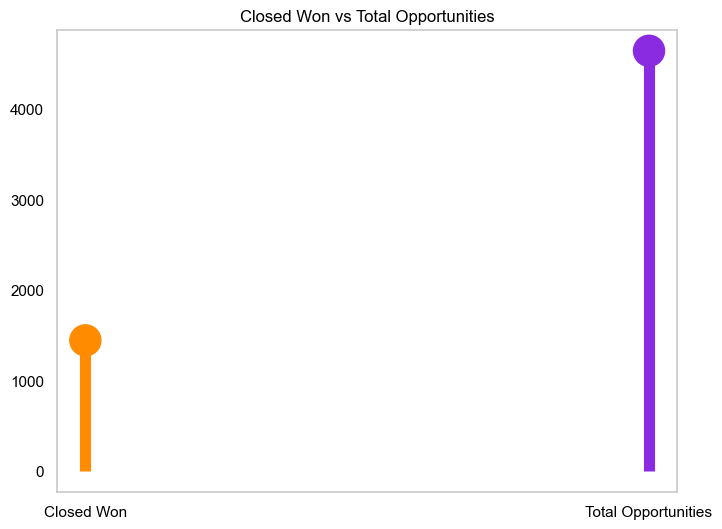

In [20]:
won_count = opportunity[opportunity["Stage"]=="Closed Won"].shape[0]

values = [won_count, total_opportunities]
labels = ["Closed Won", "Total Opportunities"]

plt.figure(figsize=(8,6))

# Draw vertical lines
plt.vlines(x=labels, ymin=0, ymax=values, color=["#FF8C00","#8A2BE2"], linewidth=8)

# Draw lollipop points (bigger)
plt.scatter(labels, values, color=["#FF8C00","#8A2BE2"], s=500)

# Remove gridlines
plt.grid(False)

plt.title("Closed Won vs Total Opportunities", color="black")

# Make tick labels black
plt.xticks(color="black")
plt.yticks(color="black")

plt.show()

---

### 17. Closed Won vs Total Closed
##### This chart shows the comparison between deals that were successfully closed and deals that were lost. It helps understand the overall success rate of completed opportunities.

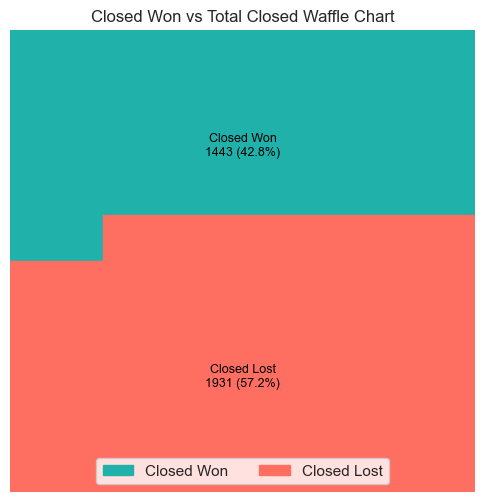

In [21]:
import numpy as np
import matplotlib.pyplot as plt

closed = opportunity[opportunity["Stage"].str.contains("Closed", na=False)]
won = opportunity[opportunity["Stage"]=="Closed Won"].shape[0]

values = [won, closed.shape[0] - won]
labels = ["Closed Won", "Closed Lost"]
colors = ["#20B2AA", "#FF6F61"]

total = sum(values)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

rows = 10
cols = 10
total_tiles = rows * cols

# number of tiles for each category
tiles_won = int(values[0] / total * total_tiles)

waffle = np.zeros((rows, cols))

tile = 0
for i in range(rows):
    for j in range(cols):
        if tile < tiles_won:
            waffle[i, j] = 0
        else:
            waffle[i, j] = 1
        tile += 1

# draw waffle
for i in range(rows):
    for j in range(cols):
        ax.add_patch(
            plt.Rectangle((j, rows-i-1), 1, 1,
            color=colors[int(waffle[i, j])])
        )

ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.axis("off")

plt.title("Closed Won vs Total Closed Waffle Chart")

# place labels inside each section (NORMAL weight)
plt.text(cols/2, rows*0.75,
         f"Closed Won\n{values[0]} ({values[0]/total*100:.1f}%)",
         ha="center", va="center",
         fontsize=9, color="black")

plt.text(cols/2, rows*0.25,
         f"Closed Lost\n{values[1]} ({values[1]/total*100:.1f}%)",
         ha="center", va="center",
         fontsize=9, color="black")

# legend
plt.legend(
    handles=[plt.Rectangle((0,0),1,1,color=c) for c in colors],
    labels=labels,
    loc="lower center",
    ncol=2
)

plt.show()

---

### 18. Expected Amount by Opportunity Type
##### This chart shows how much expected revenue comes from different product categories.

In [22]:
## formatting function
def format_number(x):
    if x >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    elif x >= 1_000:
        return f"${x/1_000:.2f}K"
    else:
        return f"${x:.2f}"

In [23]:
type_summary = (
    opportunity
    .groupby("Product Category", as_index=False)
    .agg(
        Total_Expected_Amount=("Amount", "sum"),
        Total_Opportunities=("Opportunity ID", "count")
    )
    .sort_values("Product Category")
)

type_summary["Total_Expected_Amount"] = type_summary["Total_Expected_Amount"].apply(format_number)

type_summary.style.set_properties(
    subset=["Product Category"],
    **{"font-weight": "bold"}
)

,Product Category,Total_Expected_Amount,Total_Opportunities
0,Accessories,$1.90K,7
1,Consumables,$3.87M,547
2,Service,$2.88M,225
3,System,$124.31M,1650
4,Training,$57.83K,9
5,Uncategorized,$891.39M,2208


---

### 19. Opportunities by Industry
##### This chart shows the number of opportunities coming from different industries. It helps identify which industries generate the most business opportunities.

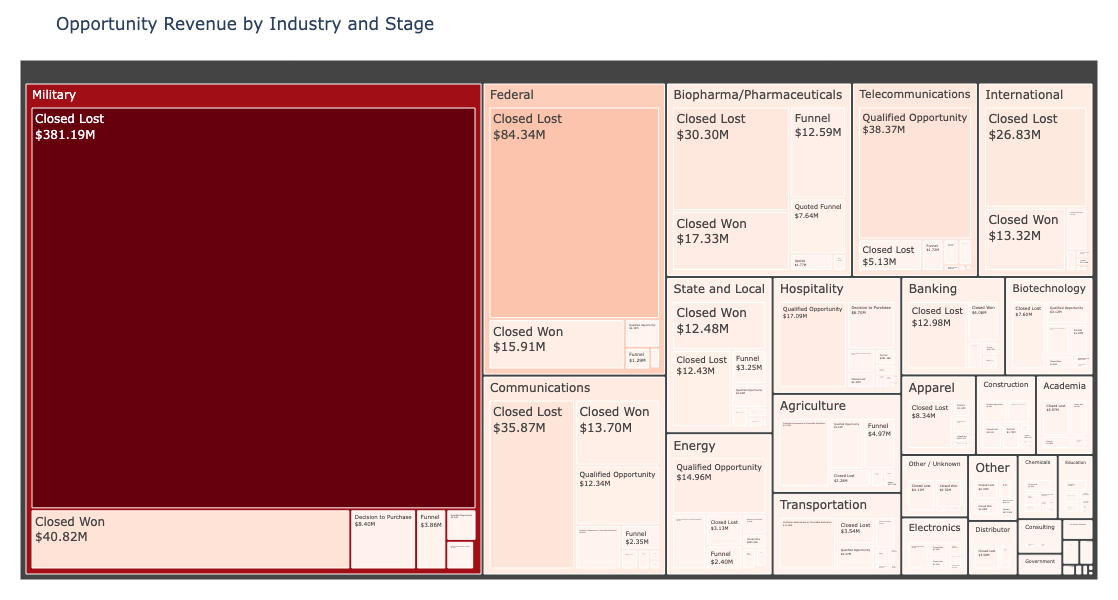

In [24]:
# Function to format numbers
def format_money(x):
    if x >= 1_000_000_000:
        return f"${x/1_000_000_000:.2f}B"
    elif x >= 1_000_000:
        return f"${x/1_000_000:.2f}M"
    elif x >= 1_000:
        return f"${x/1_000:.2f}K"
    else:
        return f"${x:.2f}"

treemap_data = (
    opportunity
    .groupby(["Industry", "Stage"])["Amount"]
    .sum()
    .reset_index()
)

# Create formatted label
treemap_data["Label_Value"] = treemap_data["Amount"].apply(format_money)

fig = px.treemap(
    treemap_data,
    path=["Industry", "Stage"],
    values="Amount",
    title="Opportunity Revenue by Industry and Stage",
    color="Amount",
    color_continuous_scale="Reds",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="%{label}<br>%{customdata}",
    customdata=treemap_data["Label_Value"]
)

fig.update_layout(
    height=600,
    margin=dict(t=60, l=20, r=20, b=20),
    coloraxis_showscale=False
)

fig.show()

##### From this analysis, we can understand how leads convert into opportunities and how opportunities turn into revenue. The charts highlight the most important industries, product categories, and deal outcomes that contribute to business growth.

---

# Machine Learning Prediction

---

#### Model imports

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

---

#### Model dictionary

In [26]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
}

---

In [27]:
categorical_cols = ["Industry", "Lead Source", "Product Category"]
numeric_cols = ["Amount"]

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [29]:
# Features
X = opportunity[["Industry","Lead Source","Product Category","Amount"]]

# Target variable
y = opportunity["Stage"].apply(lambda x: 1 if x == "Closed Won" else 0)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Model training loop

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    predictions = pipeline.predict(X_test)
    
    results[name] = accuracy_score(y_test, predictions)

# Print results
for model, score in results.items():
    print(f"{model} Accuracy: {score:.4f}")

Random Forest Accuracy: 0.7570
Gradient Boosting Accuracy: 0.7871
XGBoost Accuracy: 0.7742


---

#### Results table

In [31]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
1,Gradient Boosting,0.787097
2,XGBoost,0.774194
0,Random Forest,0.756989


---

In [32]:
# Get feature importance from trained pipeline
importances = pipeline.named_steps["model"].feature_importances_

# Get feature names from preprocessor
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

#### Feature Importance Chart (XGBoost)

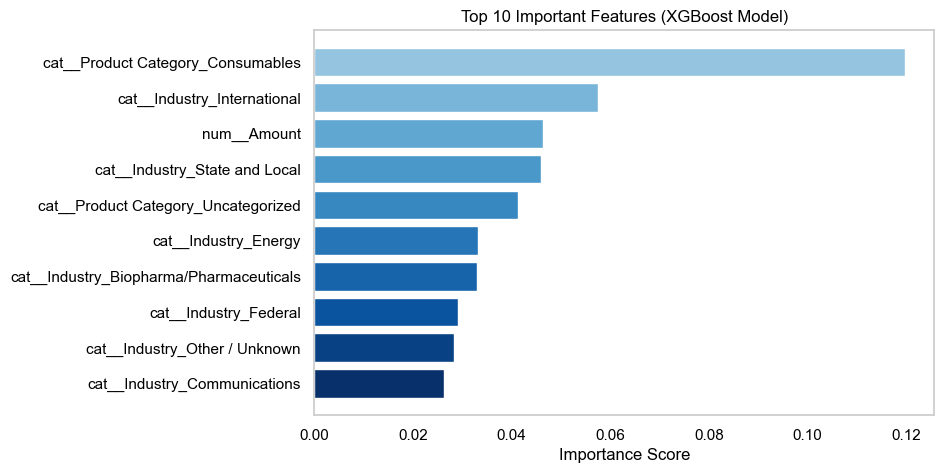

In [33]:
top_features = importance_df.head(10)

# Create gradient colors
colors = plt.cm.Blues(np.linspace(0.4, 1, len(top_features)))

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"], color=colors)

plt.gca().invert_yaxis()

# Remove gridlines
plt.grid(False)

# Title and labels
plt.title("Top 10 Important Features (XGBoost Model)", color="black")
plt.xlabel("Importance Score", color="black")

# Tick labels
plt.xticks(color="black")
plt.yticks(color="black")

plt.show()

##### The feature importance chart highlights which variables have the strongest influence on predicting opportunity outcomes. Features with higher importance scores contribute more to the model’s prediction.

---

## Confusion Matrix
##### This shows how well the model predicted Won vs Lost opportunities.

---

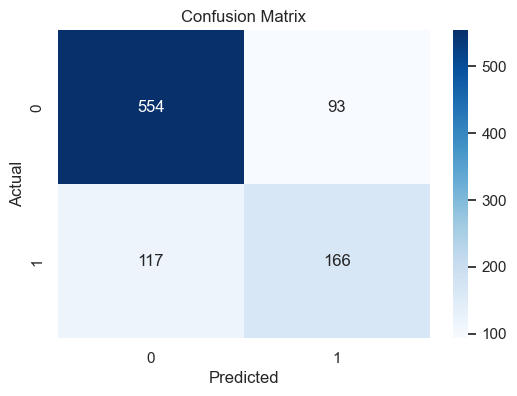

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

---

## Classification Report
##### This shows precision, recall, and F1-score.

---

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       647
           1       0.64      0.59      0.61       283

    accuracy                           0.77       930
   macro avg       0.73      0.72      0.73       930
weighted avg       0.77      0.77      0.77       930



##### Multiple machine learning models were evaluated, including Random Forest, Gradient Boosting, and XGBoost. After comparing their accuracy scores, XGBoost achieved the best performance with the highest accuracy. Therefore, XGBoost was selected as the final model to predict whether an opportunity will be won or lost.

---

## Key Insights

##### ➮ The majority of opportunities come from a few key industries, showing where the company’s strongest market demand exists.
##### ➮ Certain product categories contribute significantly more to expected revenue.
##### ➮ Some lead sources generate more successful opportunities than others.
##### ➮ The machine learning model identified product category, industry, and lead source as important factors influencing whether an opportunity is won or lost.

## Business Recommendations
##### ➮ Focus marketing efforts on the industries generating the highest number of opportunities.
##### ➮ Allocate more resources to product categories with higher expected revenue.
##### ➮ Improve lead qualification for sources that produce many leads but fewer successful conversions.
##### ➮ Use predictive models to identify high-probability opportunities and prioritize them in the sales process.

## Future Improvements
##### ➮ Improve prediction accuracy by adding more features such as customer engagement data.
##### ➮ Use advanced models such as LightGBM or CatBoost for further optimization.
##### ➮ Build a real-time dashboard for sales teams to monitor opportunities.
##### ➮ Deploy the machine learning model to predict opportunity outcomes automatically.

---

## Conclusion
#### This analysis examined lead generation, opportunity outcomes, and revenue patterns for Axon Inc. The results show that certain industries, product categories, and lead sources significantly influence sales success. The machine learning model further demonstrated that these factors can help predict whether an opportunity will be won or lost.